In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Project1.csv to Project1.csv


In [5]:
df = pd.read_csv('Project1.csv')

In [6]:
df

,Company,Type,Industry,Year Founded,Employee Count,Clients served (2025),CE Ratio
0,Bank of America,Legacy,Finance,1904,"213,000","70,000,000",328.64
1,Ant Financial,Modern,Finance,2014,"24,700","1,700,000,000",68825.91
2,Sofi,Modern,Finance,2011,"5,400","12,600,000",2333.33
3,Citigroup,Legacy,Finance,1812,"229,000","200,000,000",873.36
4,Wells Fargo,Legacy,Finance,1852,"217,000","700,000,000",3225.81
5,Chime,Modern,Finance,2013,"2,300","8,700,000",3782.61
6,Walmart,Legacy,Retail,1962,"2,100,000","256,000,000",121.90
7,Amazon,Modern,Retail,1994,"1,560,000","310,000,000",198.72
8,Warner Bros. Discovery,Legacy,Media/Streaming,1923,"35,000","128,000,000",3657.14
9,Netflix,Modern,Media/Streaming,1997,"14,000","300,000,000",21428.57


In [7]:
df.rename(columns={
    'Year Founded' : 'Founded',
    'Clients served (2025)' : 'Clients',
    'Employee Count': 'Employees',
    'CE Ratio' : 'Ratio'
}, inplace = True)

In [8]:
df

,Company,Type,Industry,Founded,Employees,Clients,Ratio
0,Bank of America,Legacy,Finance,1904,"213,000","70,000,000",328.64
1,Ant Financial,Modern,Finance,2014,"24,700","1,700,000,000",68825.91
2,Sofi,Modern,Finance,2011,"5,400","12,600,000",2333.33
3,Citigroup,Legacy,Finance,1812,"229,000","200,000,000",873.36
4,Wells Fargo,Legacy,Finance,1852,"217,000","700,000,000",3225.81
5,Chime,Modern,Finance,2013,"2,300","8,700,000",3782.61
6,Walmart,Legacy,Retail,1962,"2,100,000","256,000,000",121.90
7,Amazon,Modern,Retail,1994,"1,560,000","310,000,000",198.72
8,Warner Bros. Discovery,Legacy,Media/Streaming,1923,"35,000","128,000,000",3657.14
9,Netflix,Modern,Media/Streaming,1997,"14,000","300,000,000",21428.57


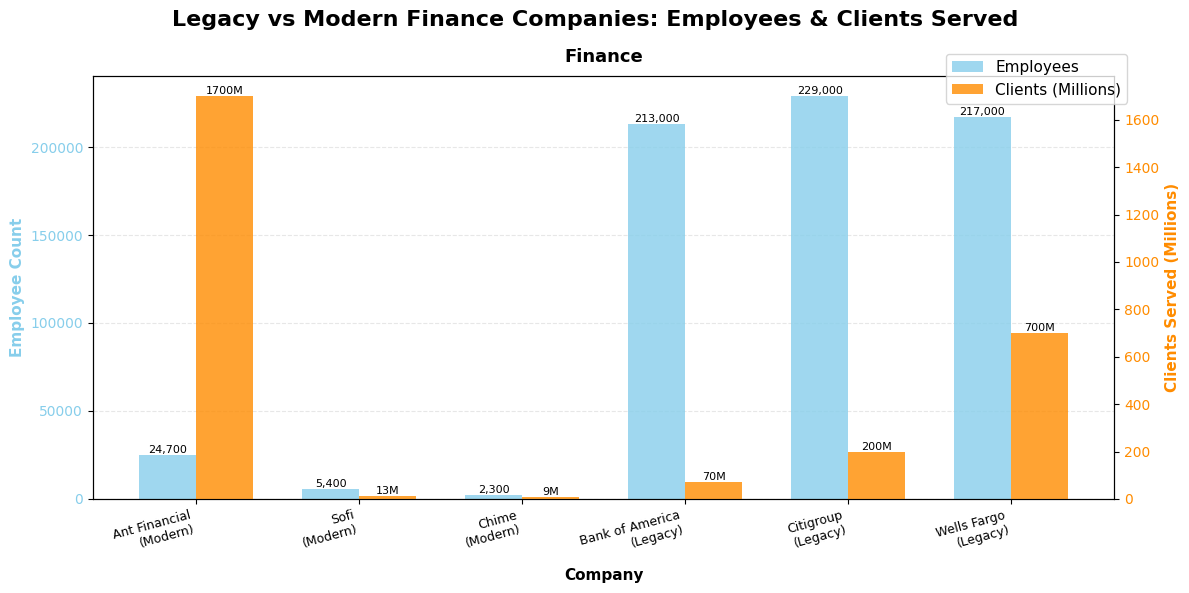

In [9]:
# Clean the Employees column (remove commas if string, otherwise keep as is)
if df['Employees'].dtype == 'object':
    df['Employees'] = df['Employees'].str.replace(',', '').astype(int)
else:
    df['Employees'] = df['Employees'].astype(int)

# Convert clients to millions for better readability
if df['Clients'].dtype == 'object':
    df['Clients (Millions)'] = df['Clients'].str.replace(',', '').astype(float) / 1_000_000
else:
    df['Clients (Millions)'] = df['Clients'].astype(float) / 1_000_000

# Filter for Finance industry only
finance_data = df[df['Industry'] == 'Finance'].sort_values('Type', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Legacy vs Modern Finance Companies: Employees & Clients Served',
             fontsize=16, fontweight='bold', y=0.98)

# Set up positions for grouped bars
x = np.arange(len(finance_data))
width = 0.35

# Create twin axis for different scales
ax2 = ax.twinx()

# Plot employees on left axis
bars1 = ax.bar(x - width/2, finance_data['Employees'],
               width, label='Employees', alpha=0.8, color='#87CEEB')

# Plot clients on right axis
bars2 = ax2.bar(x + width/2, finance_data['Clients (Millions)'],
                width, label='Clients (Millions)', alpha=0.8, color='#FF8C00')

# Customize axes
ax.set_xlabel('Company', fontsize=11, fontweight='bold')
ax.set_ylabel('Employee Count', fontsize=11, fontweight='bold', color='#87CEEB')
ax2.set_ylabel('Clients Served (Millions)', fontsize=11, fontweight='bold', color='#FF8C00')

ax.set_title('Finance', fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(x)

# Create labels with company name and type
labels = [f"{row['Company']}\n({row['Type']})"
          for _, row in finance_data.iterrows()]
ax.set_xticklabels(labels, fontsize=9, rotation=15, ha='right')

# Color the tick labels based on type
ax.tick_params(axis='y', labelcolor='#87CEEB')
ax2.tick_params(axis='y', labelcolor='#FF8C00')

# Add grid for readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}M',
             ha='center', va='bottom', fontsize=8)

# Add legend
fig.legend(['Employees', 'Clients (Millions)'],
           loc='upper right', bbox_to_anchor=(0.95, 0.92),
           fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

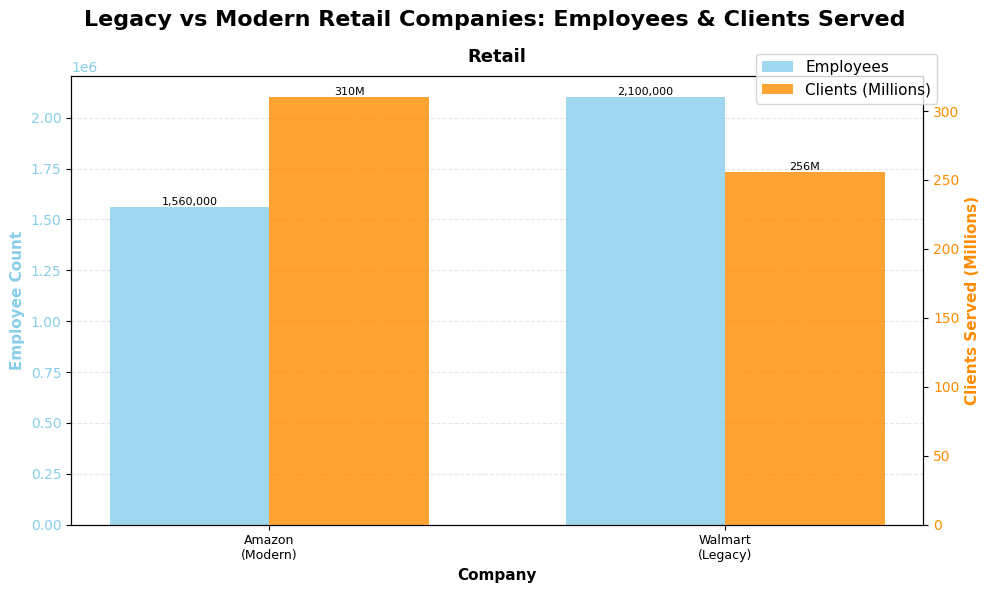

In [10]:
if df['Employees'].dtype == 'object':
    df['Employees'] = df['Employees'].str.replace(',', '').astype(int)
else:
    df['Employees'] = df['Employees'].astype(int)

# Convert clients to millions for better readability
if df['Clients'].dtype == 'object':
    df['Clients (Millions)'] = df['Clients'].str.replace(',', '').astype(float) / 1_000_000
else:
    df['Clients (Millions)'] = df['Clients'].astype(float) / 1_000_000

# Filter for Retail industry only
retail_data = df[df['Industry'] == 'Retail'].sort_values('Type', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Legacy vs Modern Retail Companies: Employees & Clients Served',
             fontsize=16, fontweight='bold', y=0.98)

# Set up positions for grouped bars
x = np.arange(len(retail_data))
width = 0.35

# Create twin axis for different scales
ax2 = ax.twinx()

# Plot employees on left axis
bars1 = ax.bar(x - width/2, retail_data['Employees'],
               width, label='Employees', alpha=0.8, color='#87CEEB')

# Plot clients on right axis
bars2 = ax2.bar(x + width/2, retail_data['Clients (Millions)'],
                width, label='Clients (Millions)', alpha=0.8, color='#FF8C00')

# Customize axes
ax.set_xlabel('Company', fontsize=11, fontweight='bold')
ax.set_ylabel('Employee Count', fontsize=11, fontweight='bold', color='#87CEEB')
ax2.set_ylabel('Clients Served (Millions)', fontsize=11, fontweight='bold', color='#FF8C00')

ax.set_title('Retail', fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(x)

# Create labels with company name and type
labels = [f"{row['Company']}\n({row['Type']})"
          for _, row in retail_data.iterrows()]
ax.set_xticklabels(labels, fontsize=9)

# Color the tick labels based on type
ax.tick_params(axis='y', labelcolor='#87CEEB')
ax2.tick_params(axis='y', labelcolor='#FF8C00')

# Add grid for readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}M',
             ha='center', va='bottom', fontsize=8)

# Add legend
fig.legend(['Employees', 'Clients (Millions)'],
           loc='upper right', bbox_to_anchor=(0.95, 0.92),
           fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

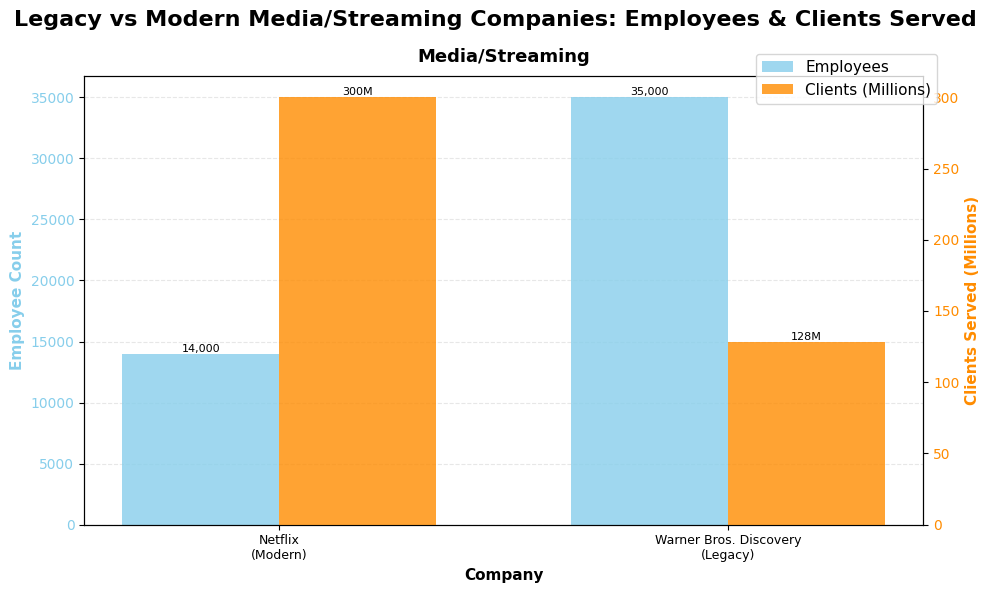

In [12]:
# Clean the Employees column (remove commas if string, otherwise keep as is)
if df['Employees'].dtype == 'object':
    df['Employees'] = df['Employees'].str.replace(',', '').astype(int)
else:
    df['Employees'] = df['Employees'].astype(int)

# Convert clients to millions for better readability
if df['Clients'].dtype == 'object':
    df['Clients (Millions)'] = df['Clients'].str.replace(',', '').astype(float) / 1_000_000
else:
    df['Clients (Millions)'] = df['Clients'].astype(float) / 1_000_000

# Filter for Media/Streaming industry only
media_data = df[df['Industry'] == 'Media/Streaming'].sort_values('Type', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Legacy vs Modern Media/Streaming Companies: Employees & Clients Served',
             fontsize=16, fontweight='bold', y=0.98)

# Set up positions for grouped bars
x = np.arange(len(media_data))
width = 0.35

# Create twin axis for different scales
ax2 = ax.twinx()

# Plot employees on left axis
bars1 = ax.bar(x - width/2, media_data['Employees'],
               width, label='Employees', alpha=0.8, color='#87CEEB')

# Plot clients on right axis
bars2 = ax2.bar(x + width/2, media_data['Clients (Millions)'],
                width, label='Clients (Millions)', alpha=0.8, color='#FF8C00')

# Customize axes
ax.set_xlabel('Company', fontsize=11, fontweight='bold')
ax.set_ylabel('Employee Count', fontsize=11, fontweight='bold', color='#87CEEB')
ax2.set_ylabel('Clients Served (Millions)', fontsize=11, fontweight='bold', color='#FF8C00')

ax.set_title('Media/Streaming', fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(x)

# Create labels with company name and type
labels = [f"{row['Company']}\n({row['Type']})"
          for _, row in media_data.iterrows()]
ax.set_xticklabels(labels, fontsize=9)

# Color the tick labels based on type
ax.tick_params(axis='y', labelcolor='#87CEEB')
ax2.tick_params(axis='y', labelcolor='#FF8C00')

# Add grid for readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}M',
             ha='center', va='bottom', fontsize=8)

# Add legend
fig.legend(['Employees', 'Clients (Millions)'],
           loc='upper right', bbox_to_anchor=(0.95, 0.92),
           fontsize=11, frameon=True)

plt.tight_layout()
plt.show()